# Project - EDA with Pandas Using the Ames Housing Data

## Introduction

In this section, you've learned a lot about importing, cleaning up, analyzing (using descriptive statistics) and visualizing data. In this more free-form project, you'll get a chance to practice all of these skills with the Ames Housing dataset, which contains housing values in the suburbs of Ames.

## Objectives

You will be able to:

* Perform a full exploratory data analysis process to gain insight about a dataset 

## Goals

Use your data munging and visualization skills to conduct an exploratory analysis of the dataset below. At a minimum, this should include:

* Loading the data (which is stored in the file ``ames_train.csv``) 
* Use built-in Python functions to explore measures of centrality and dispersion for at least 3 variables
* Create *meaningful* subsets of the data using selection operations like `.loc`, `.iloc`, or related operations.   Explain why you used the chosen subsets and do this for three possible 2-way splits. State how you think the two measures of centrality and/or dispersion might be different for each subset of the data.
* Next, use histograms and scatter plots to see whether you observe differences for the subsets of the data. Make sure to use subplots so it is easy to compare the relationships.

## Variable Descriptions
Look in ``data_description.txt`` for a full description of all variables.

A preview of some of the columns:

**MSZoning**: Identifies the general zoning classification of the sale.
		
       A	 Agriculture
       C	 Commercial
       FV	Floating Village Residential
       I	 Industrial
       RH	Residential High Density
       RL	Residential Low Density
       RP	Residential Low Density Park 
       RM	Residential Medium Density

**OverallCond**: Rates the overall condition of the house

       10	Very Excellent
       9	 Excellent
       8	 Very Good
       7	 Good
       6	 Above Average	
       5	 Average
       4	 Below Average	
       3	 Fair
       2	 Poor
       1	 Very Poor

**KitchenQual**: Kitchen quality

       Ex	Excellent
       Gd	Good
       TA	Typical/Average
       Fa	Fair
       Po	Poor

**YrSold**: Year Sold (YYYY)

**SalePrice**: Sale price of the house in dollars

In [45]:
# Let's get started importing the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [51]:
# Loading the data
df = pd.read_csv('ames_train.csv')

In [54]:
# Investigate the Data
display(df.info())
print(df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

None

(1460, 81)


In [8]:
# Investigating Distributions using scatter_matrix
num_df = df.select_dtypes(include=np.number)
num_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 38 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   LotFrontage    1201 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   OverallQual    1460 non-null   int64  
 5   OverallCond    1460 non-null   int64  
 6   YearBuilt      1460 non-null   int64  
 7   YearRemodAdd   1460 non-null   int64  
 8   MasVnrArea     1452 non-null   float64
 9   BsmtFinSF1     1460 non-null   int64  
 10  BsmtFinSF2     1460 non-null   int64  
 11  BsmtUnfSF      1460 non-null   int64  
 12  TotalBsmtSF    1460 non-null   int64  
 13  1stFlrSF       1460 non-null   int64  
 14  2ndFlrSF       1460 non-null   int64  
 15  LowQualFinSF   1460 non-null   int64  
 16  GrLivArea      1460 non-null   int64  
 17  BsmtFullBath   1460 non-null   int64  
 18  BsmtHalf

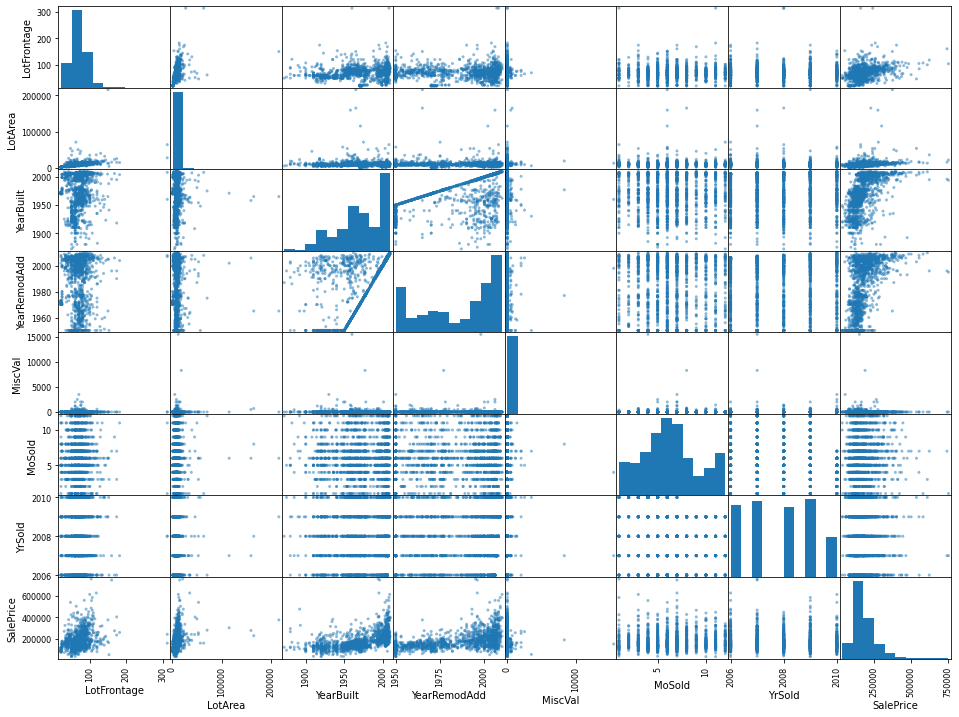

In [9]:
pd.plotting.scatter_matrix(num_df.iloc[:,[2, 3, 6, 7, 34, 35, 36, 37]], figsize=(16, 12));

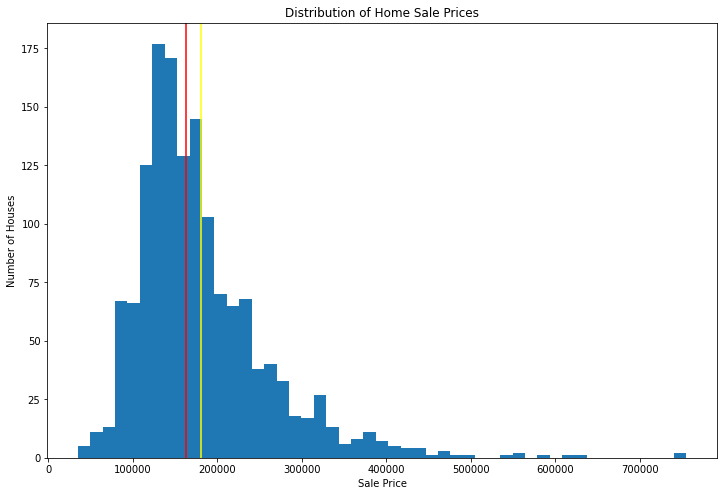

In [61]:
# Create a plot that shows the SalesPrice Distribution
fig, ax = plt.subplots(figsize=(12, 8))
ax.hist(df['SalePrice'], bins='auto')
ax.set_xlabel('Sale Price')
ax.set_ylabel('Number of Houses')
ax.set_title('Distribution of Home Sale Prices')
ax.axvline(df['SalePrice'].mean(), color='yellow')
ax.axvline(df['SalePrice'].median(), color='red')

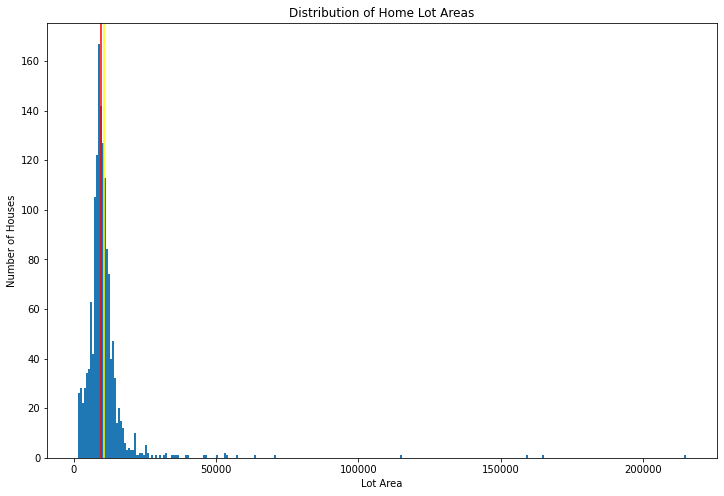

In [62]:
# Create a plot that shows the LotArea Distribution
fig, ax = plt.subplots(figsize=(12, 8))
ax.hist(df['LotArea'], bins='auto')
ax.set_xlabel('Lot Area')
ax.set_ylabel('Number of Houses')
ax.set_title('Distribution of Home Lot Areas')
ax.axvline(df['LotArea'].mean(), color='yellow')
ax.axvline(df['LotArea'].median(), color='red')

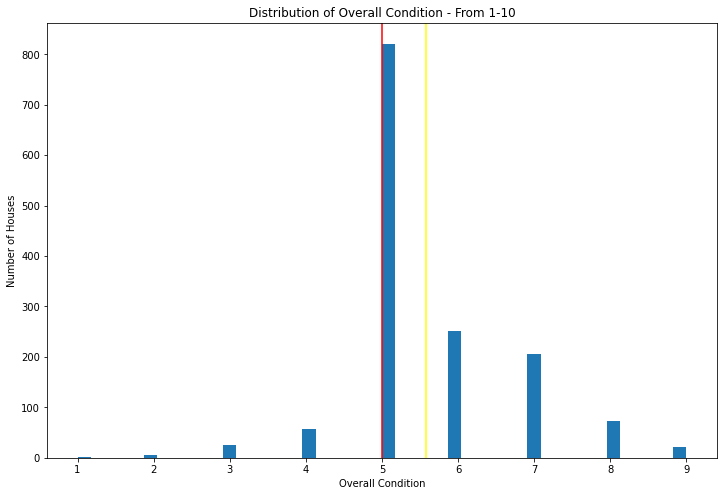

In [64]:
# Create a plot that shows the Distribution of the overall house condition
fig, ax = plt.subplots(figsize=(12, 8))
ax.hist(df['OverallCond'], bins='auto')
ax.set_xlabel('Overall Condition')
ax.set_ylabel('Number of Houses')
ax.set_title('Distribution of Overall Condition - From 1-10')
ax.axvline(df['OverallCond'].mean(), color='yellow')
ax.axvline(df['OverallCond'].median(), color='red')

Text(0.5, 1.0, 'Distribution of House Prices')

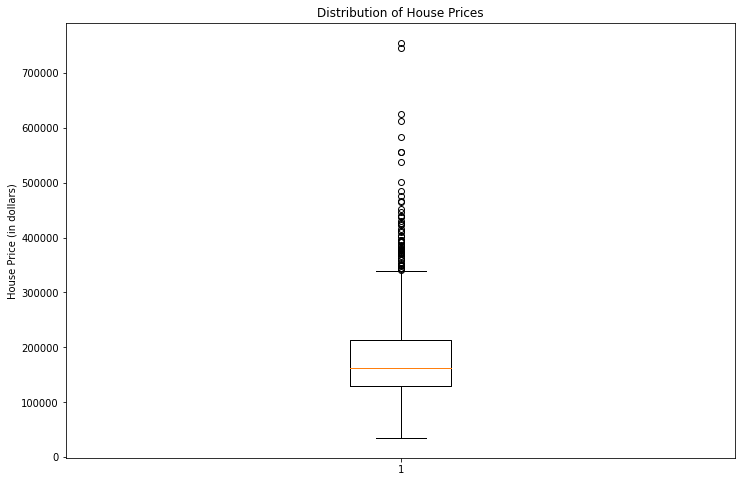

In [65]:
# Create a Box Plot for SalePrice
fig, ax = plt.subplots(figsize=(12, 8))

ax.boxplot(df['SalePrice'])
ax.set_ylabel('House Price (in dollars)')
ax.set_title('Distribution of House Prices')

Text(0.5, 1.0, 'Ages vs. Home Prices')

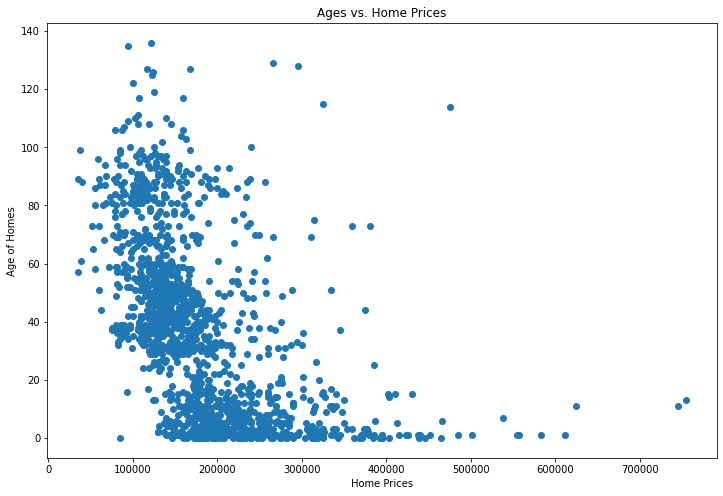

In [80]:
# Perform an Exploration of home values by age
fig, ax = plt.subplots(figsize=(12, 8))

plt.scatter(df['SalePrice'], df['age'])
ax.set_xlabel('Home Prices')
ax.set_ylabel('Age of Homes')
ax.set_title('Ages vs. Home Prices')

## Summary

Congratulations, you've completed your first "free form" exploratory data analysis of a popular dataset!